# Visualizer: Main Results (Figure 1)
---
**Context:** This notebook generates the comprehensive multi-panel Figure 1 for the manuscript. It synthesizes evidence across three distinct analytical levels:
1. **Creator Level (Panels a, b, c):** Compares the Complementary Cumulative Distribution Functions (CCDF) of creation volume and aggregate engagement returns between AIGC and HGC creators.
2. **Consumer Level (Panel d):** Evaluates consumer engagement depth (Valid-View Rate, Full-View Rate, and View Duration) based on interaction-level logs.
3. **System Level (Panel e):** Illustrates the macro-level Scale-over-Preference (SoP) dynamics mapping the relationship between relative supply scale and relative consumer preference.

### Step 1: Environment Setup
Configuring `matplotlib` with `scienceplots` for Nature-style, publication-ready aesthetics.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import norm
import seaborn as sns
import scienceplots

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')
os.environ['SEABORN_RC'] = 'False'

# Apply Nature style
plt.style.use('nature')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

print("✅ Environment initialized with 'nature' style.")

✅ Environment initialized with 'nature' style.


### Step 2: Creator Level Data Preparation
Loading and merging the creator, exposure, and creation datasets to prepare the CCDF arrays.

In [2]:
creator_dir = './'

# Load datasets
creator_df = pd.read_parquet(os.path.join(creator_dir, 'creator_v3.parquet'))
exposure_df = pd.read_parquet(os.path.join(creator_dir, 'poi_observe2.parquet'))
create_df = pd.read_parquet(os.path.join(creator_dir, 'poi_create.parquet'))

# Format columns and merge
exposure_df.columns = ['kuaishou_' + col if col != 'poi_id' else col for col in exposure_df.columns]
creator_df = creator_df.merge(exposure_df, on='poi_id', how='left').fillna(0) \
                       .merge(create_df, on='poi_id', how='left').fillna(0)

def get_ccdf(data_series: pd.Series):
    """
    Computes the Complementary Cumulative Distribution Function (CCDF).
    """
    if data_series.empty or data_series.max() == 0:
        return np.array([0]), np.array([1])
    
    value_counts = data_series.value_counts()
    value_counts_df = pd.DataFrame({data_series.name or 'value': value_counts.index, 'count': value_counts.values})
    value_counts_df = value_counts_df.sort_values(by=value_counts_df.columns[0], ascending=True)
    
    total_count = value_counts_df['count'].sum()
    value_counts_df['count'] = value_counts_df['count'] / total_count
    ccdf = 1 - value_counts_df['count'].cumsum()
    
    x = value_counts_df.iloc[:, 0].values
    y = ccdf.values
    
    if x[0] > 0:
        x = np.insert(x, 0, 0)
        y = np.insert(y, 0, 1)
        
    return x, y

print("✅ Creator data successfully loaded and merged.")

✅ Creator data successfully loaded and merged.


### Step 3: Consumer Level Data Preparation
Processing interaction logs to calculate standard errors, means, and confidence intervals for consumer engagement metrics (e.g., Valid Play Ratio, Complete Play Ratio).

In [3]:
inter_dir = './'
inter_df = pd.read_parquet(os.path.join(inter_dir, 'inter_v5.parquet'))

inter_df['inter_play_sec'] = inter_df['inter_play_duration'] / 1000.0
inter_df['photo_sec'] = inter_df['photo_duration'] / 1000.0
inter_df['type'] = inter_df['photo_is_aigc_photo'].map({0: 'HGC', 1: 'AIGC'})

# Define Valid Play rule
inter_df['inter_is_valid_play'] = np.where(
    inter_df['photo_duration'] < 7000,
    inter_df['inter_play_duration'] >= inter_df['photo_duration'],
    inter_df['inter_play_duration'] > 7000
)

binary_metrics = ['inter_is_valid_play', 'inter_is_complete_play']
continuous_metrics = ['inter_play_sec', 'photo_sec']

def compute_stats(group_df, metric, is_binary):
    mean = group_df[metric].mean()
    unique_df = group_df.drop_duplicates('ID')[metric]
    n = unique_df.count()
    var = mean * (1 - mean) if is_binary else unique_df.var(ddof=1)
    se = np.sqrt(var / n) if n > 0 else np.nan
    return mean, var, n, se

results = {}
for metric in binary_metrics + continuous_metrics:
    is_binary = metric in binary_metrics
    metric_results = {}
    for label, gid in [('HGC', 0), ('AIGC', 1)]:
        group_df = inter_df[inter_df['photo_is_aigc_photo'] == gid]
        mean, var, n, se = compute_stats(group_df, metric, is_binary)
        metric_results[label] = {'mean': mean, 'var': var, 'n': n, 'se': se}
    results[metric] = metric_results

print("✅ Consumer statistics and standard errors computed.")

✅ Consumer statistics and standard errors computed.


### Step 4: System Level Data Preparation (Scale-over-Preference)
Deriving the SoP index from the daily panel data.

In [4]:
sop_dir = './'
sop_df = pd.read_csv(os.path.join(sop_dir, 'daily_panel.csv'))
sop_df = sop_df[sop_df["date"].str.startswith(("2025-04", "2025-05"))]
daily = sop_df.copy()

x = daily["pref_ratio"].values
y = daily["scale_ratio"].values

# Calculate SoP indicator as per previous logic
daily['sop'] = np.log(daily['scale_ratio'] / daily["pref_ratio"])
print("✅ Scale-over-Preference mapping prepared.")

✅ Scale-over-Preference mapping prepared.


### Step 5: Construct Final Multi-Panel Figure
Merging all subplots (Creator CCDFs, Consumer Bar/Box, System SoP) into a comprehensive publication-ready `GridSpec` layout.

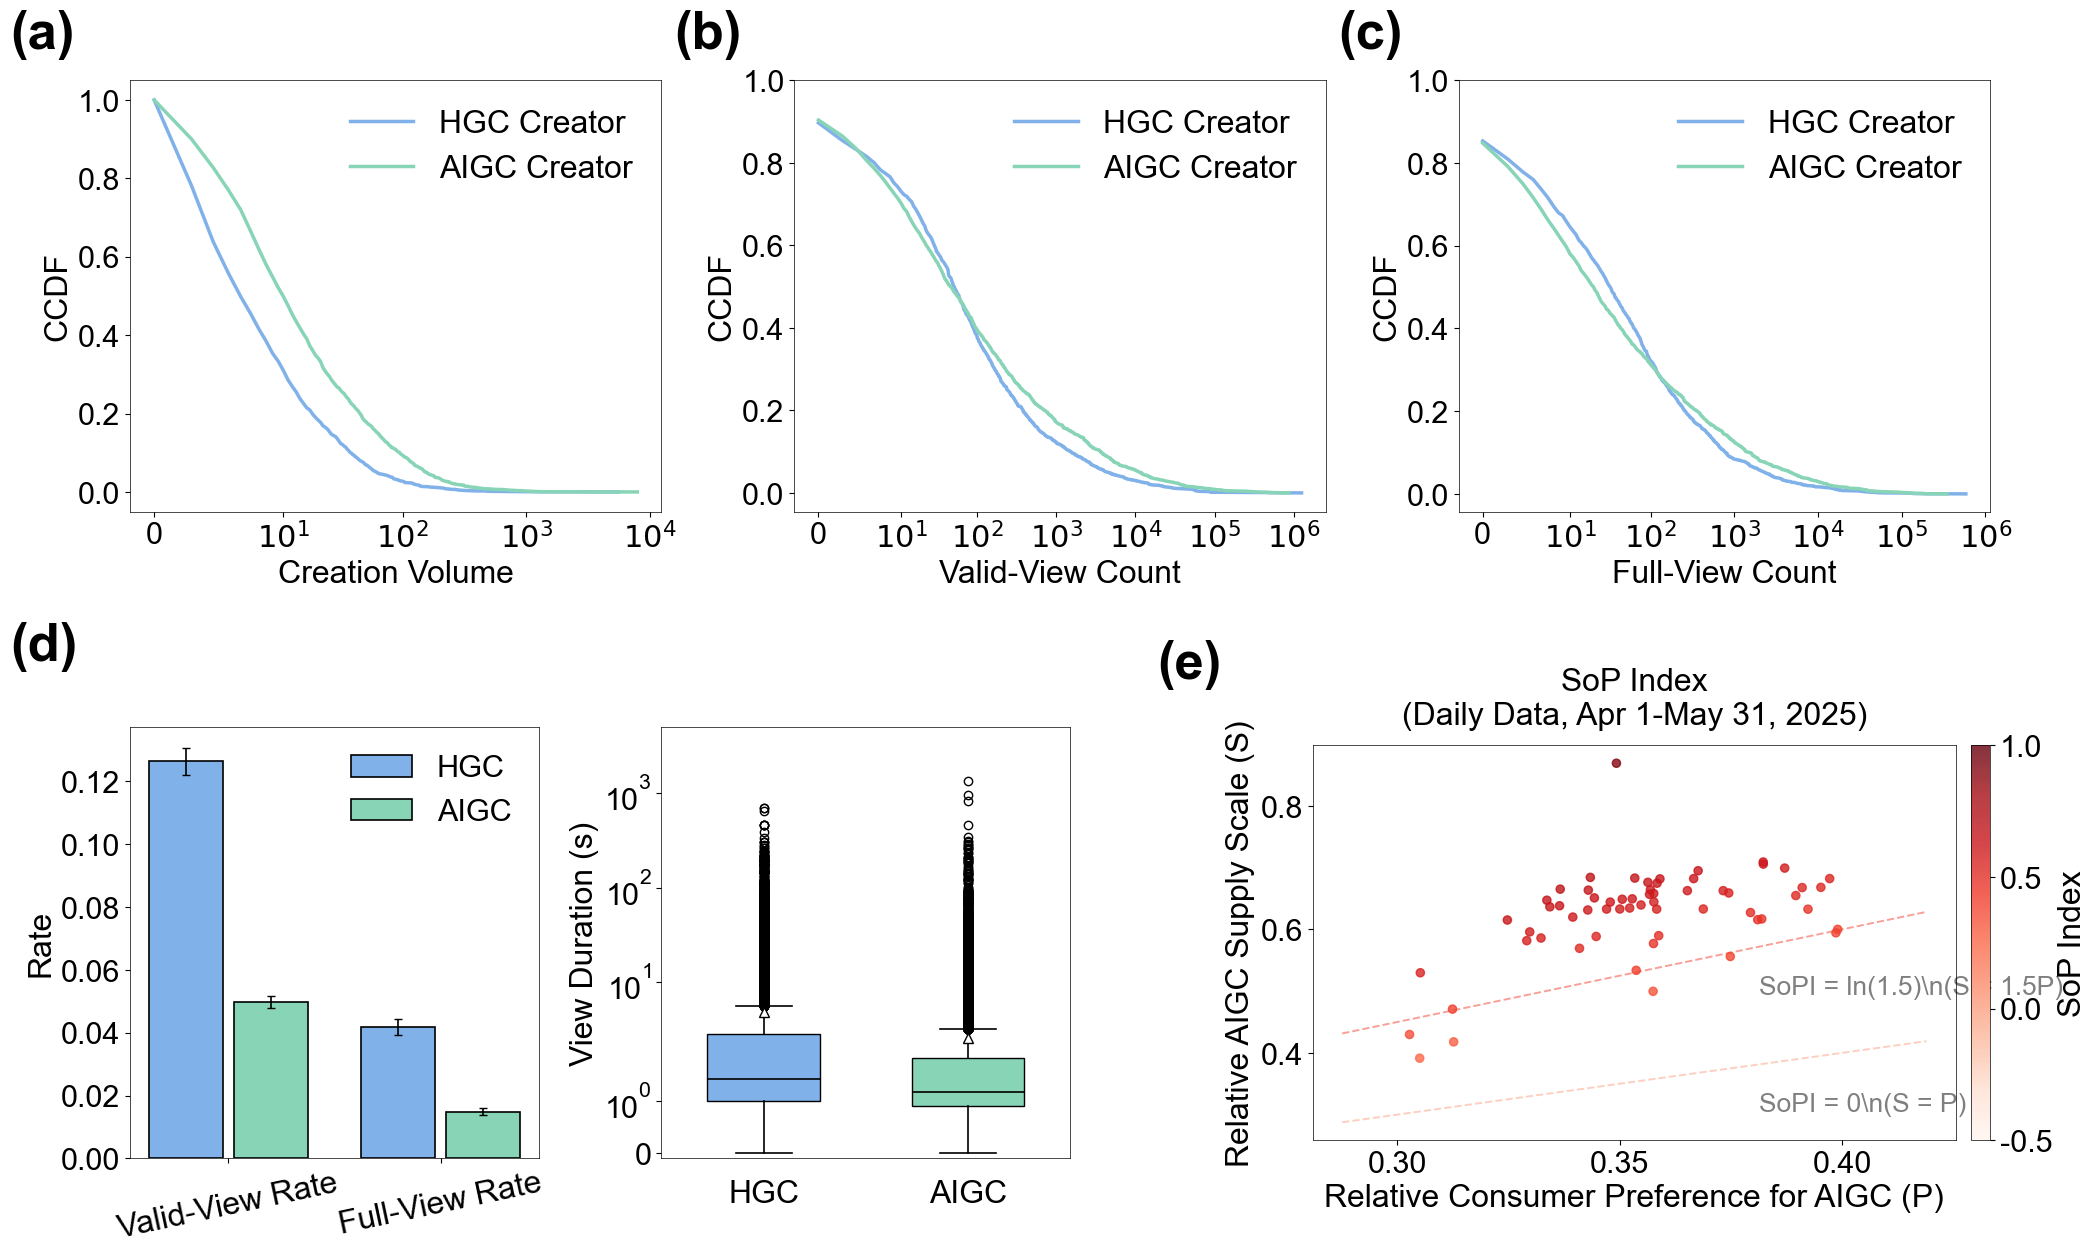

🎉 Figure 1 successfully generated and saved!


In [7]:
# ========== Configuration ========== 
FIGSIZE = (24, 14)
FONT_SIZE = 23
LINE_WIDTH = 2.5

COLOR_NON = "#81b1e9"
COLOR_AI = "#88d4b7"
COLOR_HGC = "#81b1e9"
COLOR_AIGC = "#88d4b7"

data_groups = {
    "Creation Volume": {"nonaigc": "kuaishou_nonaigc_video_cnt", "all": "kuaishou_all_video_cnt"},
    "Valid-View Count": {"nonaigc": "kuaishou_nonaigc_valid_play_cnt", "all": "kuaishou_all_valid_play_cnt"},
    "Full-View Count": {"nonaigc": "kuaishou_nonaigc_complete_play_cnt", "all": "kuaishou_all_complete_play_cnt"}
}

fig = plt.figure(figsize=FIGSIZE)
gs_main = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.25, height_ratios=[1, 1], width_ratios=[1, 1, 1])

# ==========================================
# ROW 1: Creator CCDF Plots (Panels a, b, c)
# ==========================================
creator_axes = [fig.add_subplot(gs_main[0, 0]), fig.add_subplot(gs_main[0, 1]), fig.add_subplot(gs_main[0, 2])]

for idx, ((group_name, cols), ax) in enumerate(zip(data_groups.items(), creator_axes)):
    data_dict = {
        "HGC Creator": creator_df.loc[creator_df["treatment"] == 0, cols["nonaigc"]],
        "AIGC Creator": creator_df.loc[creator_df["treatment"] == 1, cols["all"]],
    }
    for label, data_series in data_dict.items():
        x, y = get_ccdf(data_series)
        ax.plot(x, y, color=(COLOR_NON if label == "HGC Creator" else COLOR_AI), 
                linewidth=LINE_WIDTH, label=label)
    
    ax.set_xscale('function', functions=(lambda x: np.log10(x + 1), lambda y: 10**y - 1))
    x_max = x.max() if len(x) > 0 else 1
    ticks = [0] + [10**k for k in range(1, int(np.log10(x_max + 1)) + 2)]
    ax.set_xticks(ticks)
    ax.set_xticklabels(['0'] + [rf'$10^{int(np.log10(t))}$' for t in ticks[1:]])
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_xlabel(group_name, fontsize=FONT_SIZE)
    ax.set_ylabel("CCDF", fontsize=FONT_SIZE)
    ax.tick_params(labelsize=FONT_SIZE - 1)
    ax.legend(loc="upper right", frameon=False, fontsize=FONT_SIZE)

# ==========================================
# ROW 2: Layout Splitting
# ==========================================
gs_bottom = gs_main[1, :].subgridspec(1, 2, width_ratios=[1, 0.72], wspace=0.3)
gs_left = gs_bottom[0].subgridspec(1, 2, width_ratios=[1,1], wspace=0.3)
ax_bar = fig.add_subplot(gs_left[0])
ax_box = fig.add_subplot(gs_left[1])

# ==========================================
# ROW 2 Left: Consumer Barplot (Panel d.1)
# ==========================================
plot_metrics = ["Valid-View Rate", "Full-View Rate"]
# ⚠️ SAFE-GUARD: Explicitly define CI array derived from earlier SE computations to prevent missing variable errors.
bar_data = pd.DataFrame({
    "Metric": ["Valid-View Rate", "Valid-View Rate", "Full-View Rate", "Full-View Rate"],
    "Group": ["HGC", "AIGC", "HGC", "AIGC"],
    "Mean": [
        results["inter_is_valid_play"]["HGC"]["mean"],
        results["inter_is_valid_play"]["AIGC"]["mean"],
        results["inter_is_complete_play"]["HGC"]["mean"],
        results["inter_is_complete_play"]["AIGC"]["mean"]
    ],
    "CI": [
        results["inter_is_valid_play"]["HGC"]["se"] * 1.96,
        results["inter_is_valid_play"]["AIGC"]["se"] * 1.96,
        results["inter_is_complete_play"]["HGC"]["se"] * 1.96,
        results["inter_is_complete_play"]["AIGC"]["se"] * 1.96
    ]
})

x_idx = np.arange(len(plot_metrics))
bar_width, group_gap = 0.35, 0.05
offsets = {"HGC": -(bar_width/2 + group_gap/2), "AIGC": +(bar_width/2 + group_gap/2)}

fig2_linewidth = 1.2
for group in ["HGC", "AIGC"]:
    sub_df = bar_data[bar_data["Group"] == group]
    means = sub_df["Mean"].values
    cis = sub_df["CI"].values  # Properly extracted CI values
    xpos = x_idx + offsets[group]
    ax_bar.bar(xpos, means, width=bar_width, label=group, 
               color=(COLOR_HGC if group == "HGC" else COLOR_AIGC), 
               edgecolor='black', linewidth=fig2_linewidth)
    ax_bar.errorbar(xpos, means, yerr=cis, fmt='none', ecolor='black', 
                    elinewidth=fig2_linewidth, capsize=3)

ax_bar.set_xticks(x_idx)
ax_bar.set_xticklabels(plot_metrics, fontsize=FONT_SIZE - 1)
ax_bar.tick_params(labelsize=FONT_SIZE - 1, axis='y')
ax_bar.tick_params(labelsize=FONT_SIZE, axis='x', rotation=12)
ax_bar.set_ylabel("Rate", fontsize=FONT_SIZE)
ax_bar.legend(loc="upper right", frameon=False, fontsize=FONT_SIZE - 1)
ax_bar.grid(True, alpha=0, axis='y')

# ==========================================
# ROW 2 Middle: Consumer Boxplot (Panel d.2)
# ==========================================
hgc_data = inter_df[inter_df['type'] == 'HGC']['inter_play_sec']
aigc_data = inter_df[inter_df['type'] == 'AIGC']['inter_play_sec']

bplot = ax_box.boxplot(
    [hgc_data, aigc_data], positions=[1, 2], widths=0.55, patch_artist=True,
    showmeans=True, meanline=False,
    meanprops={"marker": "^", "markeredgecolor": "black", "markerfacecolor": "white", "markersize": 7},
    whiskerprops=dict(color='black', linewidth=fig2_linewidth),
    capprops=dict(color='black', linewidth=fig2_linewidth),
    medianprops=dict(color='black', linewidth=fig2_linewidth)
)
bplot['boxes'][0].set_facecolor(COLOR_HGC)
bplot['boxes'][1].set_facecolor(COLOR_AIGC)

ax_box.set_yscale("symlog")
ax_box.set_ylabel("View Duration (s)", fontsize=FONT_SIZE)
ax_box.set_ylim(-0.1, 5000)
ax_box.set_xticks([1, 2])
ax_box.set_xticklabels(["HGC", "AIGC"], fontsize=FONT_SIZE)
ax_box.tick_params(axis='x', length=0, labelsize=FONT_SIZE, pad=15)
ax_box.tick_params(axis='y', labelsize=FONT_SIZE - 1, direction="out")
ax_box.grid(True, alpha=0, axis='y')

# ==========================================
# ROW 2 Right: System SoP Plot (Panel e)
# ==========================================
ax_sop = fig.add_subplot(gs_bottom[1])

# Force square layout and alignment
sop_pos = ax_sop.get_position()
square_size = min(sop_pos.width, sop_pos.height)
ax_sop.set_position([sop_pos.x1 - square_size, sop_pos.y0 + (sop_pos.height - square_size) / 2, square_size, square_size])

vmin, vmax = -0.5, 1
cmap = plt.get_cmap('Reds')
scatter = ax_sop.scatter(
    daily["pref_ratio"], daily["scale_ratio"],
    c=daily["sop"], cmap=cmap, s=35, alpha=0.8, vmin=vmin, vmax=vmax,
)

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax_sop)
cax = divider.append_axes("right", size="3%", pad=0.15)
cb = plt.colorbar(scatter, cax=cax)
cb.set_label(r'SoP Index', fontsize=FONT_SIZE)
cb.ax.tick_params(labelsize=FONT_SIZE - 1)
cb.ax.set_yticks([-0.5, 0.0, 0.5, 1.0])

min_x, max_x = daily["pref_ratio"].min(), daily["pref_ratio"].max()
x_line = np.linspace(min_x * 0.95, max_x * 1.05, 500)
x_line = x_line[x_line < 0.999]

def sop_curve(x, C): return np.exp(C) * x

sop_rates = [1, 1.5]
sop_labels = [r"SoPI = 0\n(S = P)", r"SoPI = ln(1.5)\n(S = 1.5P)"]
sop_offsets = [-150, -150]

for rate, label_text, offset_idx in zip(sop_rates, sop_labels, sop_offsets):
    level = np.log(rate)
    color = cmap((level - vmin) / (vmax - vmin))
    y_line = np.array([sop_curve(xx, level) if 0 < xx < 1 else np.nan for xx in x_line])
    valid_mask = ~np.isnan(y_line)
    if np.any(valid_mask):
        ax_sop.plot(x_line[valid_mask], y_line[valid_mask], 'k--', linewidth=1.4, alpha=0.5, color=color)
        last_idx = np.where(valid_mask)[0][offset_idx]
        ax_sop.annotate(
            label_text, xy=(x_line[last_idx], y_line[last_idx]-0.075),
            xytext=(5, 0), textcoords='offset points', fontsize=FONT_SIZE - 4, alpha=0.5
        )

ax_sop.set_xticks([0.3, 0.35, 0.4])
ax_sop.set_xlabel(r"Relative Consumer Preference for AIGC (P)", fontsize=FONT_SIZE)
ax_sop.set_ylabel(r"Relative AIGC Supply Scale (S)", fontsize=FONT_SIZE)
ax_sop.set_title("SoP Index\n(Daily Data, Apr 1-May 31, 2025)", fontsize=FONT_SIZE, pad=15)
ax_sop.tick_params(labelsize=FONT_SIZE-1)

plt.tight_layout()

# ==========================================
# Add Subplot Labels (c, d, e)
# ==========================================
anchor_axes = [creator_axes[0], creator_axes[1], creator_axes[2], ax_bar, ax_sop]
labels = ['(a)', '(b)' , '(c)', '(d)', '(e)']
x_offsets, y_offsets = [0.05, 0.05 , 0.05 , 0.05, 0.065], [0.015, 0.015, 0.015, 0.04, 0.04]

for ax, label, x_off, y_off in zip(anchor_axes, labels, x_offsets, y_offsets):
    bbox = ax.get_position()
    fig.text(bbox.x0 - x_off, bbox.y1 + y_off, label,
             fontsize=FONT_SIZE + 15, fontweight='bold', fontfamily='Arial',
             va='bottom', ha='left')

plt.savefig('fig1.pdf', dpi=1200, bbox_inches='tight', pad_inches=0.05)
plt.show()

print("🎉 Figure 1 successfully generated and saved!")